In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
pd.set_option('display.max_columns',None) # to display all columns 
sns.set_style('whitegrid')
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('german_credit_data.csv')
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,996,40,male,3,own,little,little,3857,30,car,good
997,997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [3]:
df['Age'].describe()

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64

In [4]:
df['Risk'].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [6]:
df.describe(include='all').T #Transpose

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df['Job'].unique()

array([2, 1, 3, 0], dtype=int64)

In [8]:
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df=df.dropna().reset_index(drop=True)

In [11]:
df.drop(columns='Unnamed: 0',inplace=True)

In [12]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

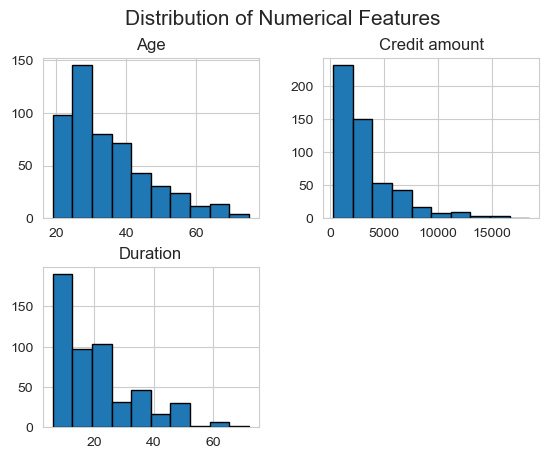

In [13]:
df[['Age','Credit amount','Duration']].hist(bins=10,edgecolor='black')
plt.suptitle('Distribution of Numerical Features',fontsize=15)
plt.show()

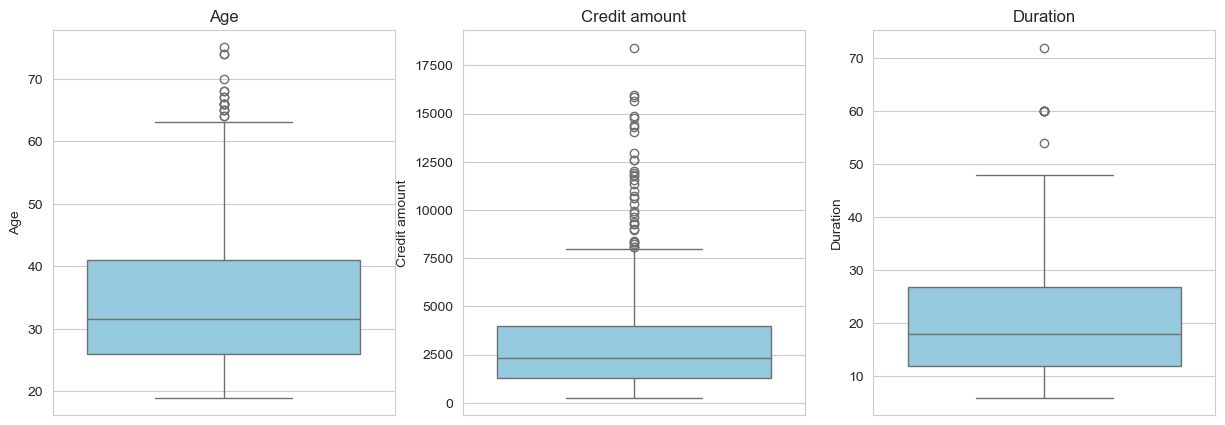

In [14]:
# Numerical Features 
plt.figure(figsize=(15,5))
for i , col in enumerate (['Age','Credit amount','Duration']):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=df[col],color='skyblue')
    plt.title(col)
    

In [15]:
df['Credit amount'].skew()

2.0615363128603597

In [16]:
#df['Credit amount']=np.log1p(df['Credit amount'])

<Axes: >

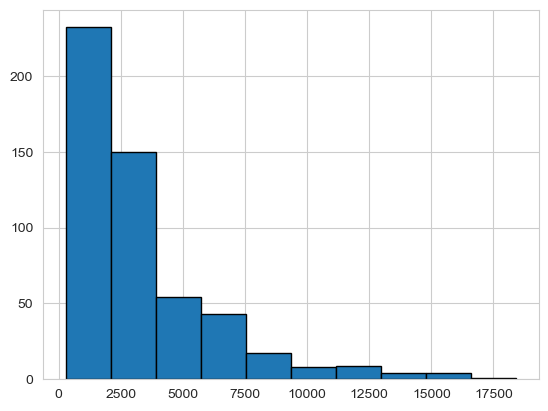

In [17]:
df['Credit amount'].hist(bins=10,edgecolor='black')

In [18]:
df.query('Duration>=60')

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
176,24,female,3,own,moderate,moderate,7408,60,car,bad
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,27,male,3,own,little,moderate,14027,60,car,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


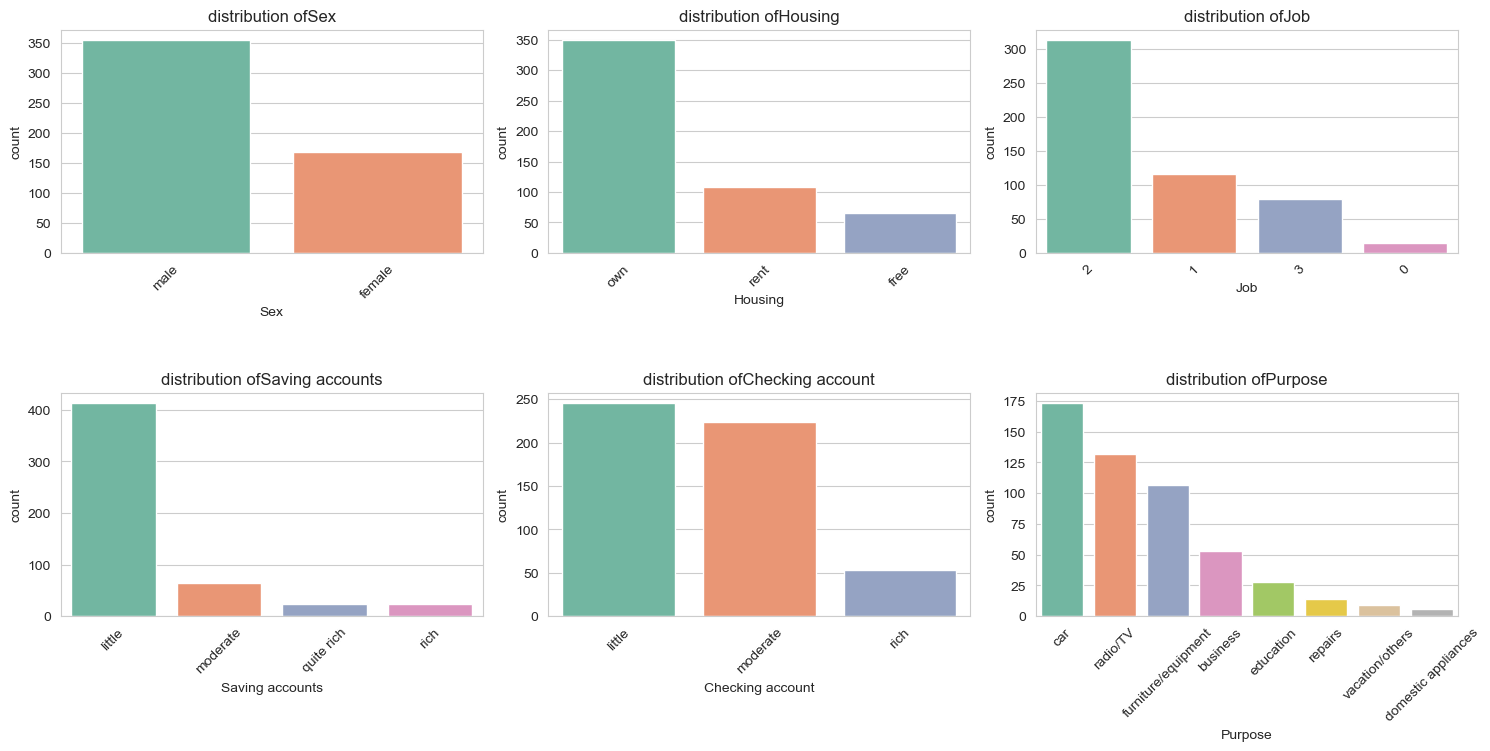

In [19]:

categorcal_cols = ['Sex','Housing','Job','Saving accounts','Checking account','Purpose']
plt.figure(figsize=(15,10))
for i , col in enumerate (categorcal_cols):
    plt.subplot(3,3,i+1)
    sns.countplot(data=df,x=col, palette='Set2',order=df[col].value_counts().index)
    plt.title(f'distribution of{col}')
    plt.xticks(rotation=45)
    plt.tight_layout()

In [20]:
corr=df[['Age','Job','Credit amount','Duration']].corr()

In [21]:
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


<Axes: >

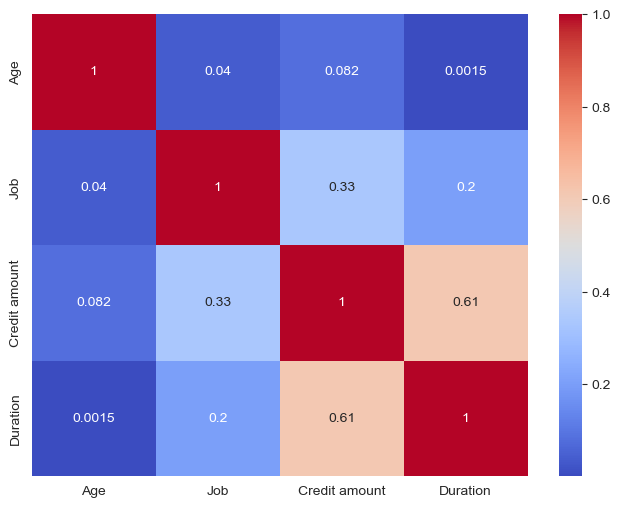

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')

<Axes: xlabel='Job', ylabel='Credit amount'>

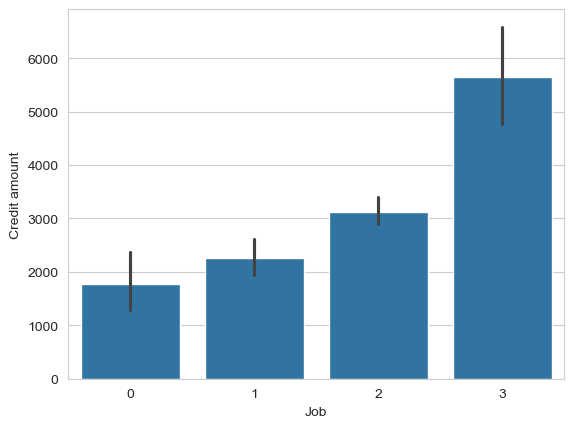

In [23]:
df.groupby('Job')['Credit amount'].mean()
sns.barplot(
    data=df,
    x='Job',
    y='Credit amount',
    estimator=np.mean
)
#This called Aggregation analysis which is mean here : 
#Does the type of job affect the loan amount???


In [24]:
pd.pivot_table(df,
               values='Credit amount',
               index='Housing',
               columns='Purpose')
#Does the average loan amount vary..
#depending on the housing and the purpose of the loan?

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


Text(0.5, 1.0, 'Credit amount vs Age colored by sex and sized by Duration ')

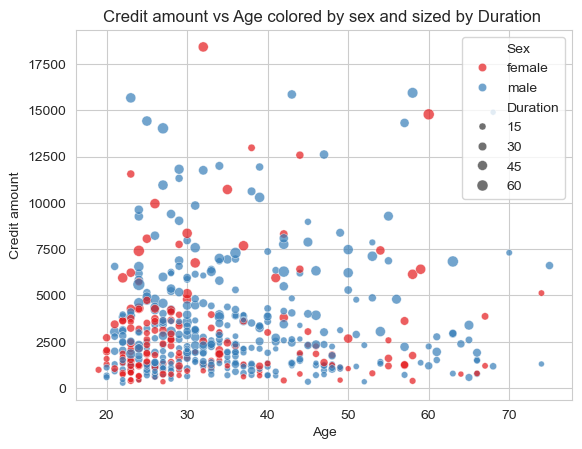

In [25]:
#Multivariate Analysis
sns.scatterplot(data=df,
               x='Age',
               y='Credit amount',
               hue='Sex',
               size='Duration',
               alpha=.7,
               palette='Set1')
plt.title('Credit amount vs Age colored by sex and sized by Duration ')
#Do older people take larger loans?


Text(0.5, 1.0, 'Credit amount Distribution by Saving Accounts')

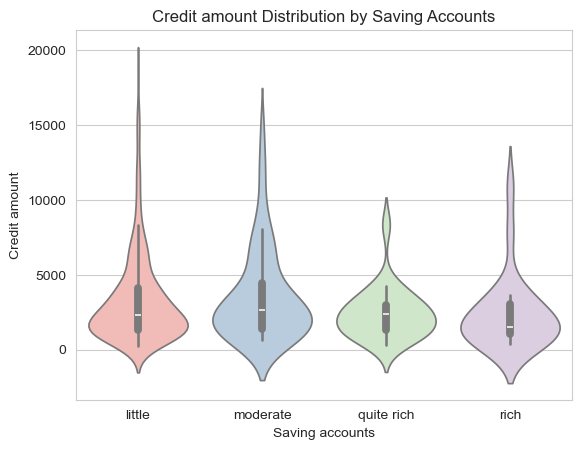

In [26]:
sns.violinplot(data=df, x='Saving accounts',
               y='Credit amount', palette='Pastel1')
plt.title('Credit amount Distribution by Saving Accounts')

In [27]:
df['Risk'].value_counts(normalize=True)*100
# It counts (proportion)the number of times each unique value appears in the column.

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

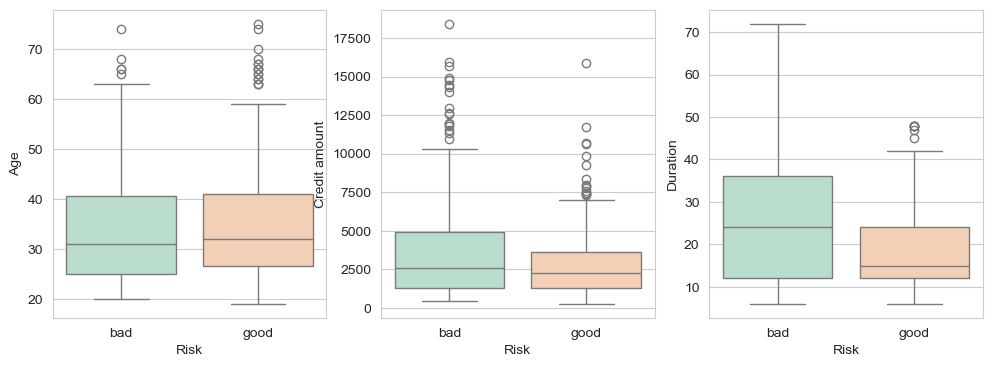

In [28]:
plt.figure(figsize=(12,4))
for i, col in enumerate(['Age','Credit amount', 'Duration']):
    plt.subplot(1,3,i+1)
    sns.boxplot(data=df, x='Risk',y=col,palette='Pastel2')


In [29]:
df.groupby('Risk')[['Age','Credit amount', 'Duration']].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


In [30]:
categorcal_cols

['Sex', 'Housing', 'Job', 'Saving accounts', 'Checking account', 'Purpose']

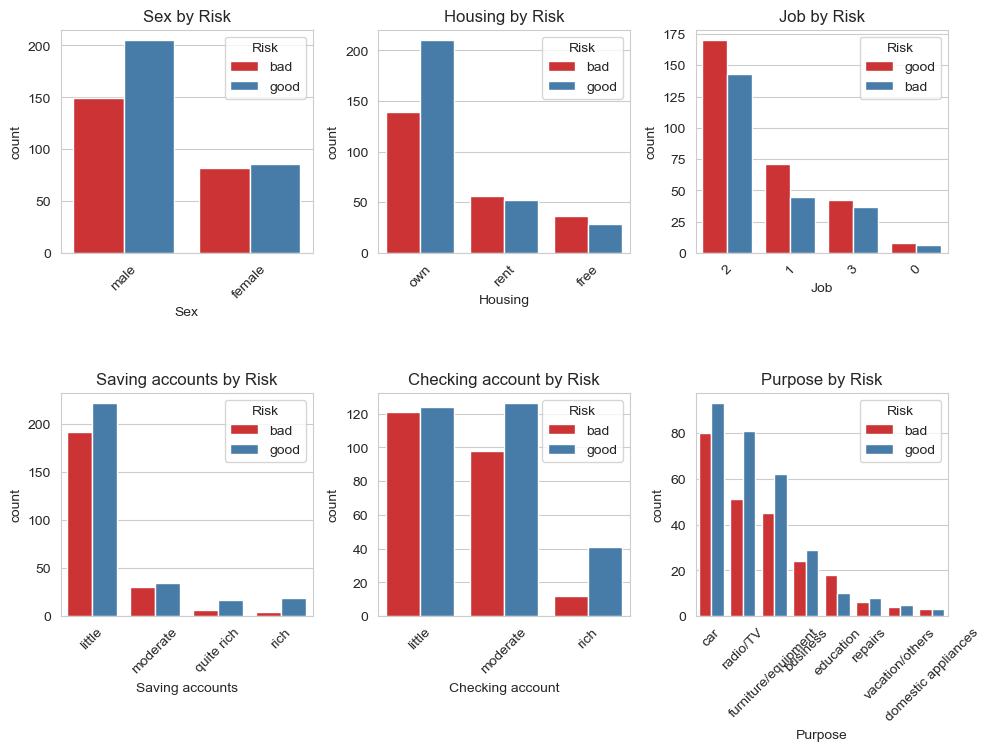

In [31]:
plt.figure(figsize=(10,10))
for i , col in enumerate (categorcal_cols):
    plt.subplot(3,3,i+1)
    sns.countplot(data =df, x=col, hue='Risk',palette='Set1', order=df[col].value_counts().index)
    plt.title(f'{col} by Risk')
    plt.xticks(rotation=45)
    plt.tight_layout()
    
                  


In [32]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [33]:
features=['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account','Credit amount', 'Duration']

In [34]:
target='Risk'

In [35]:
df_model=df[features+[target]].copy()

In [36]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [37]:
from sklearn.preprocessing import LabelEncoder
# LE .from Scikit-learn for converting  (Categories) into numbers.

import joblib

In [38]:
cat_cols=df_model.select_dtypes(include='object').columns.drop('Risk')

In [39]:
le_dict={}
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='object')

In [40]:
for col in cat_cols:
    le=LabelEncoder()
    df_model[col]=le.fit_transform(df_model[col])
    le_dict[col]=le
    joblib.dump(le, f'{col}_encoder.pkl')
#joblib.dump(object, filename)
#joblib Module
#dump() is a function for saving.(object)


In [41]:
le_target = LabelEncoder()
target

'Risk'

In [42]:
df_model[target] = le_target.fit_transform(df_model[target])

In [43]:
df_model[target].value_counts()
#1.good(Lower Risk) 
#2.bad(High Risk)

Risk
1    291
0    231
Name: count, dtype: int64

In [44]:
joblib.dump(le_target, "target_encoder.pkl")
#here i will save le target with name target_encoder

['target_encoder.pkl']

In [45]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,0,2,1,0,1,5951,48,0
1,45,1,2,0,0,0,7882,42,1
2,53,1,2,0,0,0,4870,24,0
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,0


In [46]:
df_model['Saving accounts'].value_counts()

Saving accounts
0    412
1     64
2     23
3     23
Name: count, dtype: int64

In [47]:
df['Saving accounts'].value_counts()

Saving accounts
little        412
moderate       64
quite rich     23
rich           23
Name: count, dtype: int64

In [48]:
from sklearn.model_selection import train_test_split

In [49]:
X=df_model.drop(target, axis=1)

In [50]:
y = df_model[target]

In [51]:
X

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration
0,22,0,2,1,0,1,5951,48
1,45,1,2,0,0,0,7882,42
2,53,1,2,0,0,0,4870,24
3,35,1,3,2,0,1,6948,36
4,28,1,3,1,0,1,5234,30
...,...,...,...,...,...,...,...,...
517,48,1,1,1,0,1,1743,24
518,30,1,3,1,0,0,3959,36
519,40,1,3,1,0,0,3857,30
520,23,1,2,0,0,0,1845,45


In [52]:
target

'Risk'

In [53]:
X_train, X_test , y_train, y_test =train_test_split(X, y, test_size =0.2, stratify= y, random_state=1)
# test size = 20% test .. 80% train
#stratify=y ..Maintains the same proportions.(Important)
#example >> Original70% good 30% bad
# Train 70% good 30% bad
#random_state=1 Reproducibility 

In [54]:
X_train.shape

(417, 8)

In [55]:
X_test.shape

(105, 8)

In [56]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [57]:
import pkgutil

print("xgboost" in [m.name for m in pkgutil.iter_modules()])

True


In [58]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [59]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier#adds more randomness
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV # find best hyperparameter cv = CrossValidation

In [60]:
def train_model (model, param_grid, X_train, y_train, X_test, y_test):
    grid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy',n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    acc=accuracy_score(y_test, y_pred)
    return best_model, acc, grid.best_params_

In [61]:
dt = DecisionTreeClassifier (random_state=1, class_weight='balanced')
dt_param_grid = {
    'max_depth': [3,5,7,10,None],
    'min_samples_split' : [2,5,10],
    'min_samples_leaf' : [1,2,4]
}
# random_state=1 = The Same results every Time
# class_weight='balanced' Mean that Bad is allso Important to me not just Good 

In [62]:
best_dt, acc_dt, params_dt = train_model(dt, dt_param_grid, X_train, y_train, X_test, y_test)

In [63]:
print ("Decision Tree Accuracy", acc_dt)

Decision Tree Accuracy 0.580952380952381


In [64]:
print ("Best parameters", params_dt)

Best parameters {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [65]:
rf = RandomForestClassifier(random_state=1, class_weight='balanced', n_jobs=-1)

In [66]:
rf_param_grid={
    "n_estimators": [100,200],
    "max_depth": [5,7,10, None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf":[1,2,4]
} 
#n_estimators = How many trees do u want to create

In [67]:
best_rf, acc_rf, params_rf = train_model(rf, rf_param_grid,X_train, y_train, X_test, y_test)

In [68]:
print("Random Forest Accuracy", acc_rf)

Random Forest Accuracy 0.6190476190476191


In [69]:
print("Best Params", params_rf)

Best Params {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


In [70]:
et=ExtraTreesClassifier(random_state=1,class_weight="balanced")

In [71]:
et_param_grid={
    "n_estimators": [100,200],
    "max_depth": [5,7,10, None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf":[1,2,4]
} 
#n_estimators = How many trees do u want to create

In [72]:
best_et, acc_et, params_et = train_model(et, et_param_grid,X_train, y_train, X_test, y_test)

In [73]:
print ('Extra_Trees_Accuracy', acc_et)

Extra_Trees_Accuracy 0.6476190476190476


In [74]:
print("Best params", params_et)

Best params {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [75]:
xgb=XGBClassifier(random_state=1, n_jobs=-1,
                  scale_pos_weight= (y_train==0).sum()/ (y_train==1).sum(),
                  use_label_encoder=False,
                 eval_metric="logloss")
# we dont have class weight here so our data not balance
# y_train==0.sum collect for me all the zeros and sum = 300 
# y_train ==1.sum =700
#300/700 .43 which mean customize all the weight to not ignore the lowest 
# use label encoder flase mean = actully we did encoder 
#eval_metric="logloss" did the model Trust in her predicts 
# LogLoss isn't a measure of success, it's a measure of error.

In [76]:
xgb_param_grid={
    "n_estimator" : [100,200],
    "max_depth" : [3,5,7],
    "learning_rate" : [.01,.1,.2],
    "subsample": [.7,1],
    "colsample_bytree":[.7,1]    
}
#learning_rate = every tree will learn from the last mistake
#subsample = evert will use 70% and 100 from the tree we do this we dont need them to be the same 
#colsample_bytree = every tree will use 70% from the features age, amount and so on 

In [77]:
best_xgb, acc_xgb, params_xgb = train_model(xgb, xgb_param_grid,X_train, y_train, X_test, y_test)

In [78]:
print('XGB Accuracy', acc_xgb)

XGB Accuracy 0.6571428571428571


In [79]:
print ("Best params", params_xgb)

Best params {'colsample_bytree': 0.7, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimator': 100, 'subsample': 1}


In [80]:
best_et.predict(X_test)

array([1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1])

In [81]:
joblib.dump(best_et, 'extra_trees_credit_model.pkl')
#save the model that trained without train it again 
#joblib=A library for saving and loading Python objects, especially ML models.
#dump=(Serialize) = Any conversion of the object in memory to a file on the device.
#best_et = The model 
#extra_trees_credit_model = The file name 

['extra_trees_credit_model.pkl']

In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

model= joblib.load('extra_trees_credit_model.pkl')

encoder = {
    col: joblib.load(f"{col}_encoder.pkl")
    for col in ['Sex','Housing','Saving accounts','Checking account']
}

st.title("Credit Risk Prediction App")
st.write("Enter applicant information to predict if the credit risk is good or bad")

age = st.number_input("Age",min_value=18,max_value=80)
sex = st.selectbox("Sex", encoder['Sex'].classes_)
job = st.number_input("Job(0-3)",min_value=0,max_value=3,value=1)
housing = st.selectbox("Housing", encoder['Housing'].classes_)
saving_accounts = st.selectbox("Saving accounts", encoder['Saving accounts'].classes_)
checking_account = st.selectbox("Checking account", encoder['Checking account'].classes_)
credit_amount = st.number_input("Credit amount",min_value=0,value=1000)
duration = st.number_input("Duration(Month)",min_value=1,value=12)

input_df = pd.DataFrame({
    "Age":[age],
    "Sex":[encoder['Sex'].transform([sex])[0]],
    "Job":[job],
    "Housing":[encoder['Housing'].transform([housing])[0]],
    "Saving accounts":[encoder['Saving accounts'].transform([saving_accounts])[0]],
    "Checking account":[encoder['Checking account'].transform([checking_account])[0]],
    "Credit amount":[credit_amount],
    "Duration":[duration]
})

if st.button('Predict Risk'):
    pred = model.predict(input_df)[0]

    if pred == 1:
        st.success("The predicted credit risk is: GOOD")
    else:
        st.error("The predicted credit risk is: BAD")

In [ ]:
!python -m streamlit run app.py